**## Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


**## Upload Dataset**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


**## Load Dataset**

In [4]:
import pandas as pd

df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9994
Columns: 21


**## Dataset Preview**

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**## Dataset Information**

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


**## Check Missing Values**

In [7]:
missing_values = df.isnull().sum()

print(missing_values)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


**## Prepare Dates**

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%B")

print("Date columns prepared successfully!")

Date columns prepared successfully!


**## Calculate KPIs**

In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
units_sold = df["Quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Units Sold:", units_sold)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Units Sold: 37873
Profit Margin: 12.47 %


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


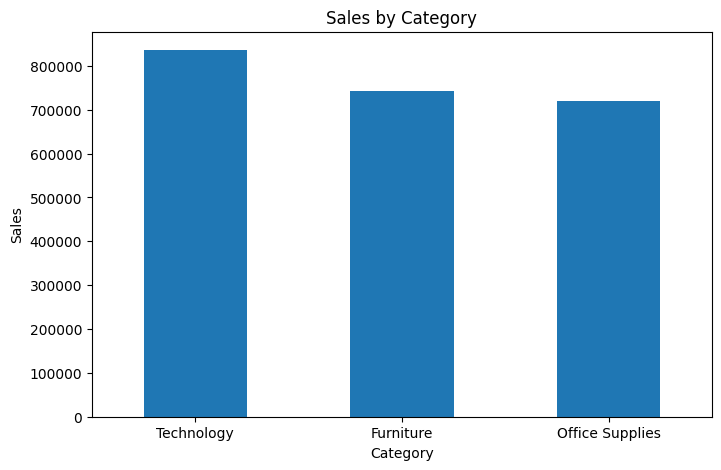

In [12]:
import matplotlib.pyplot as plt

sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_category)

sales_by_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


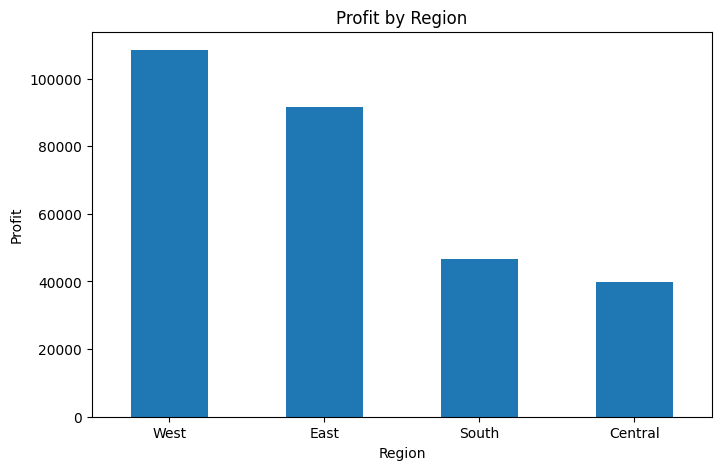

In [13]:
profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_region)

profit_by_region.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


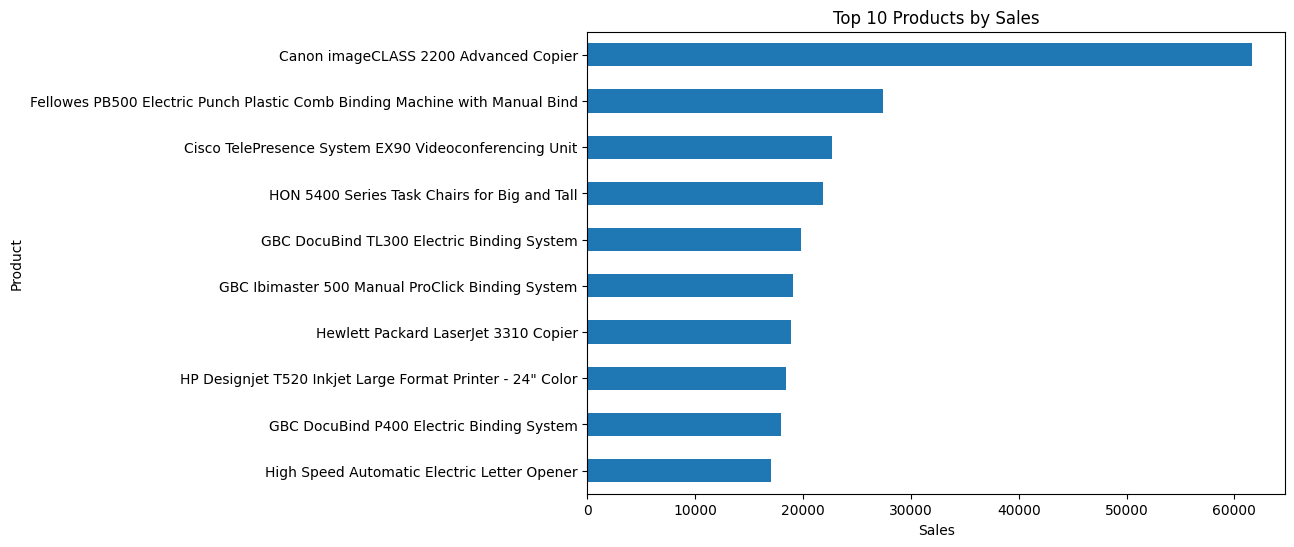

In [14]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

top_products.sort_values().plot(
    kind="barh",
    figsize=(9,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

**## Final Dashboard Summary**

In [15]:
dashboard_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Units Sold",
        "Profit Margin"
    ],
    "Value": [
        round(total_sales, 2),
        round(total_profit, 2),
        units_sold,
        round(profit_margin, 2)
    ]
})

dashboard_summary

,KPI,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Units Sold,37873.00
3,Profit Margin,12.47


**## Save Clean Dataset**

In [16]:
output_file = "Task3_Sample_Superstore_Dashboard_Data.csv"

df.to_csv(output_file, index=False)

print("Task 3 dataset saved successfully!")
print(output_file)

Task 3 dataset saved successfully!
Task3_Sample_Superstore_Dashboard_Data.csv


**Download**

In [17]:
from google.colab import files

files.download("Task3_Sample_Superstore_Dashboard_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>